# Spatial Overview

## 1. Setup

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("../").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.style import setup_style
from src.plotting import plot_sky_distribution, plot_density_maps

setup_style(fontsize=12)

ROOT = Path("../")
FIG_DIR = ROOT / "figures"

## 2. Load volume-limited catalogue

In [4]:
df_F = pd.read_csv(ROOT / "data" / "processed" / "gcs-Fstars-complete.csv")
df_G = pd.read_csv(ROOT / "data" / "processed" / "gcs-Gstars-complete.csv")
df_all = pd.read_csv(ROOT / "data" / "processed" / "gcs-allstars-complete.csv")

print(f"F-type stars: {len(df_F):,}")
print(f"G-type stars: {len(df_G):,}")
print(f"Total: {len(df_all):,}")

F-type stars: 1,475
G-type stars: 1,298
Total: 2,773


## 3. Figure 1: Sky distribution

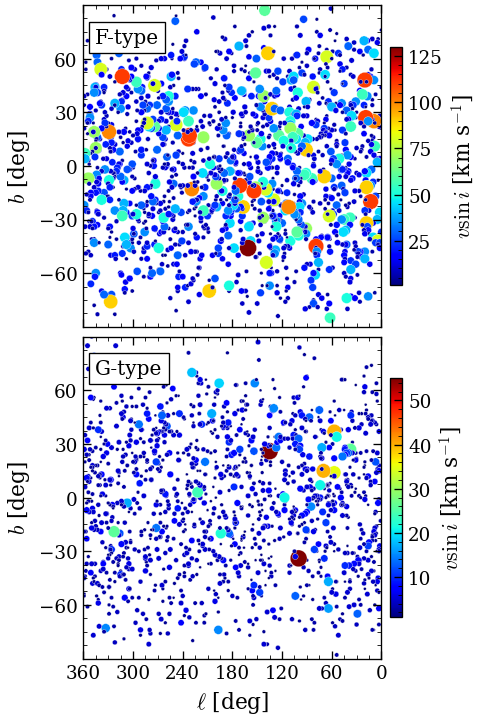

In [5]:
fig1, ax1 = plot_sky_distribution(df_F, df_G, figsize=(4, 6), cmap="jet")
# fig1.savefig(FIG_DIR / "sky_distribution.pdf")
plt.show()

## 4. Figure 2: Star-count density maps

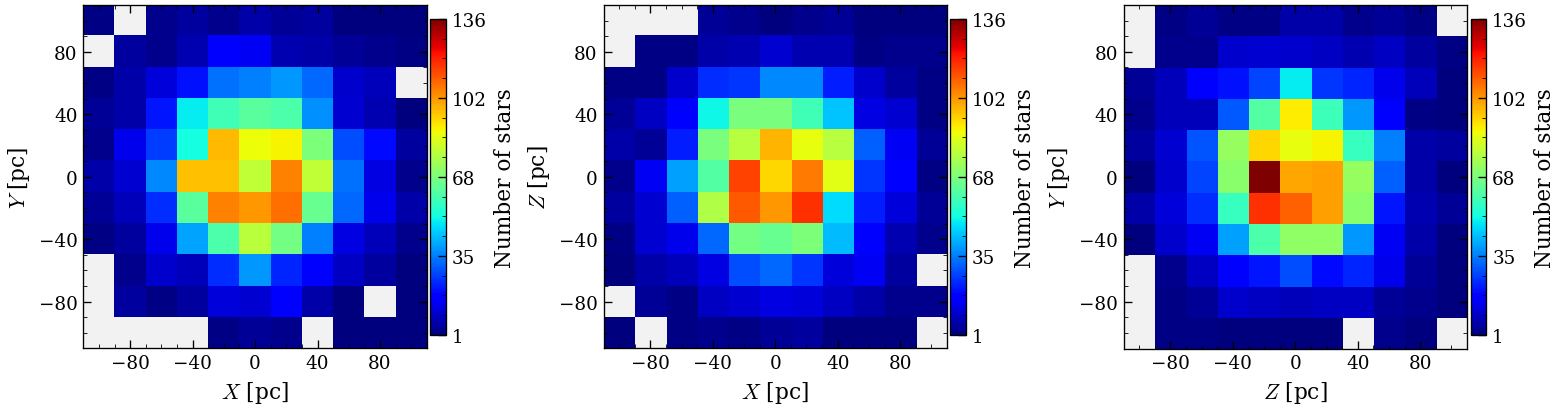

In [6]:
fig2, ax2 = plot_density_maps(df_all, ul=150, tc=20, interpolate=False, cmap="jet")
# fig2.savefig(FIG_DIR / "density_maps.pdf")
plt.show()

## 5. Quick sample statistics

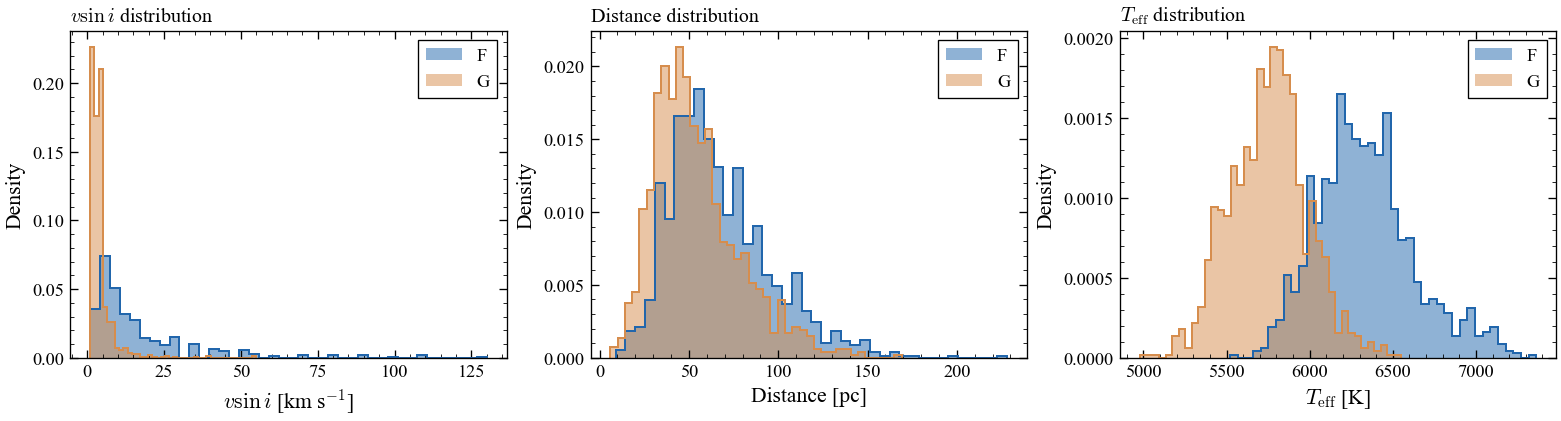

In [6]:
COLORS = {"F": "#2166ac", "G": "#d68d4d", "ALL": "#404040"}

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

# vsini distribution
ax = axes[0]
for df, lbl, c in [(df_F, "F", COLORS["F"]), (df_G, "G", COLORS["G"])]:
    ax.hist(
        df["vsini"],
        bins=40,
        color=c,
        alpha=0.5,
        label=lbl,
        density=True,
        histtype="stepfilled",
    )
    ax.hist(df["vsini"], bins=40, color=c, histtype="step", density=True, lw=1.2)
ax.set_xlabel(r"$v\sin i$ [km s$^{-1}$]")
ax.set_ylabel("Density")
ax.set_title(r"$v\sin i$ distribution", loc="left")
ax.legend()

# Distance distribution
ax = axes[1]
for df, lbl, c in [(df_F, "F", COLORS["F"]), (df_G, "G", COLORS["G"])]:
    ax.hist(
        df["Dist"],
        bins=40,
        color=c,
        alpha=0.5,
        label=lbl,
        density=True,
        histtype="stepfilled",
    )
    ax.hist(df["Dist"], bins=40, color=c, histtype="step", density=True, lw=1.2)
ax.set_xlabel("Distance [pc]")
ax.set_ylabel("Density")
ax.set_title("Distance distribution", loc="left")
ax.legend()

# Teff distribution
ax = axes[2]
for df, lbl, c in [(df_F, "F", COLORS["F"]), (df_G, "G", COLORS["G"])]:
    ax.hist(
        df["Teff"],
        bins=40,
        color=c,
        alpha=0.5,
        label=lbl,
        density=True,
        histtype="stepfilled",
    )
    ax.hist(df["Teff"], bins=40, color=c, histtype="step", density=True, lw=1.2)
ax.set_xlabel(r"$T_{\rm eff}$ [K]")
ax.set_ylabel("Density")
ax.set_title(r"$T_{\rm eff}$ distribution", loc="left")
ax.legend()

# fig.savefig(FIG_DIR / "fig_sample_statistics.pdf")
plt.show()